In [20]:
from datetime import datetime, timedelta

import pandas as pd
import requests

In [21]:
from datetime import datetime, UTC

now = datetime.now(UTC)

print(now)

2026-07-08 12:00:48.392601+00:00


In [25]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

In [26]:
from weatherlab.synop import get_raw_synop

In [27]:
df = get_raw_synop()

https://www.ogimet.com/cgi-bin/getsynop?begin=202607081200&end=202607081200&state=Bang&lang=eng


In [28]:
from weatherlab.synop import get_raw_synop

df = get_raw_synop()

df.head()

https://www.ogimet.com/cgi-bin/getsynop?begin=202607081200&end=202607081200&state=Bang&lang=eng


,WMOIND,YEAR,MONTH,DAY,HOUR,MIN,REPORT


In [29]:
df.iloc[0]["REPORT"]

IndexError: single positional indexer is out-of-bounds

In [8]:
from pymetdecoder import synop

report = "AAXX 07064 41850 11350 80503 10263 20250 39919 40017 60164 76362 8572/ 333 56299 58015 70190 83708 84615 88458="

decoded = synop.SYNOP().decode(report)

decoded

{'station_type': {'value': 'AAXX'},
 'obs_time': {'day': {'value': 7}, 'hour': {'value': 6}},
 'wind_indicator': {'value': 4, 'unit': 'KT', 'estimated': False},
 'station_id': {'value': '41850'},
 'region': {'value': 'II'},
 'precipitation_indicator': {'value': 1,
  'in_group_1': True,
  'in_group_3': False},
 'weather_indicator': {'value': 1, 'automatic': False},
 'lowest_cloud_base': {'_table': '1600',
  'min': 200,
  'max': 300,
  'quantifier': None,
  '_code': 3,
  'unit': 'm'},
 'visibility': {'_table': '4377',
  'value': 5000,
  'quantifier': None,
  'use90': False,
  '_code': 50,
  'unit': 'm'},
 'cloud_cover': {'_table': '2700',
  'value': 8,
  'obscured': False,
  'unit': 'okta',
  '_code': 8},
 'surface_wind': {'direction': {'_table': '0877',
   'value': 50,
   'varAllUnknown': False,
   'calm': False,
   '_code': 5,
   'unit': 'deg'},
  'speed': {'value': 3, 'unit': 'KT'}},
 'air_temperature': {'value': 26.3, 'unit': 'Cel'},
 'dewpoint_temperature': {'value': 25.0, 'unit': '

In [9]:
len(df)

49

In [10]:
from pymetdecoder import synop

decoder = synop.SYNOP()

report = df.iloc[0]["PARTE"]

decoded = decoder.decode(report)

decoded["air_temperature"]["value"]

26.3

In [11]:
from pymetdecoder import synop
import pandas as pd

decoder = synop.SYNOP()

records = []

for _, row in df.iterrows():

    try:
        d = decoder.decode(row["PARTE"])

        records.append({
            "wmo": d["station_id"]["value"],
            "temp": d.get("air_temperature", {}).get("value"),
            "dewpoint": d.get("dewpoint_temperature", {}).get("value"),
            "slp": d.get("sea_level_pressure", {}).get("value"),
            "wind_dir": d.get("surface_wind", {}).get("direction", {}).get("value"),
            "wind_speed": d.get("surface_wind", {}).get("speed", {}).get("value"),
        })

    except Exception as e:
        print("Failed:", row["PARTE"][:40], e)

obs = pd.DataFrame(records)

obs.head()

Failed: AAXX 07064 41902 NIL= expected string or bytes-like object, got 'InvalidGroup'
Failed: AAXX 07064 41939 NIL= expected string or bytes-like object, got 'InvalidGroup'
Failed: AAXX 07064 41944 NIL= expected string or bytes-like object, got 'InvalidGroup'
Failed: AAXX 07064 41955 NIL= expected string or bytes-like object, got 'InvalidGroup'
Failed: AAXX 07064 41980 NIL= expected string or bytes-like object, got 'InvalidGroup'
Failed: AAXX 07064 41989 NIL= expected string or bytes-like object, got 'InvalidGroup'
Failed: AAXX 07064 41998 NIL= expected string or bytes-like object, got 'InvalidGroup'


,wmo,temp,dewpoint,slp,wind_dir,wind_speed
0,41850,26.3,25.0,1001.7,50.0,3
1,41851,26.6,26.0,1001.8,120.0,1
2,41856,31.1,25.0,1001.7,130.0,1
3,41858,30.0,27.0,1001.6,90.0,5
4,41859,31.9,27.0,1001.4,130.0,2


In [12]:
obs.shape

(42, 6)

In [13]:
sorted(obs["wmo"].unique())[:10]

['41850',
 '41851',
 '41856',
 '41858',
 '41859',
 '41863',
 '41881',
 '41883',
 '41886',
 '41888']

In [14]:
from weatherlab.stationdb import StationDB

db = StationDB()

db.download()

Saved to cache/isd-history.csv


In [15]:
import pandas as pd

stations = pd.read_csv("cache/isd-history.csv")

print(stations.shape)

stations.head()

(29661, 11)


,USAF,WBAN,STATION NAME,CTRY,STATE,ICAO,LAT,LON,ELEV(M),BEGIN,END
0,007018,99999,WXPOD 7018,NaN,NaN,NaN,0.00,0.000,7018.0,20110309,20130730
1,007026,99999,WXPOD 7026,AF,NaN,NaN,0.00,0.000,7026.0,20120713,20170822
2,007070,99999,WXPOD 7070,AF,NaN,NaN,0.00,0.000,7070.0,20140923,20150926
3,008260,99999,WXPOD8270,NaN,NaN,NaN,0.00,0.000,0.0,20050101,20120731
4,008268,99999,WXPOD8278,AF,NaN,NaN,32.95,65.567,1156.7,20100519,20120323


In [16]:
stations.columns.tolist()

['USAF',
 'WBAN',
 'STATION NAME',
 'CTRY',
 'STATE',
 'ICAO',
 'LAT',
 'LON',
 'ELEV(M)',
 'BEGIN',
 'END']

In [17]:
obs["wmo"].iloc[0]

'41850'

In [1]:
from pyoscar import OSCARClient

client = OSCARClient()

stations = client.get_stations(
    country="BGD"
)

print(len(stations))

print(type(stations[0]))

print(stations[0])


5


KeyError: 0

In [2]:
print(type(stations))

print(stations.keys())

<class 'dict'>
dict_keys(['totalCount', 'pageCount', 'pageNumber', 'itemsPerPage', 'stationSearchResults'])


In [3]:
results = stations["stationSearchResults"]

print(type(results))
print(len(results))
print(results[0])

<class 'list'>
56
{'id': 6335, 'name': 'BADALGACHHI, NAOGAON', 'region': 'Asia', 'territory': 'Bangladesh', 'declaredStatus': 'Operational', 'latitude': 24.5805555556, 'longitude': 88.5366666667, 'hp': 18, 'stationTypeName': 'Land (fixed)', 'wigosStationIdentifiers': [{'wigosStationIdentifier': '0-20000-0-41881', 'primary': True}], 'wigosId': '0-20000-0-41881', 'stationTypeId': 1, 'dateEstablished': '2016-04-28T00:00:00.000+00:00', 'stationStatusCode': 'operational', 'stationTypeCode': 'landOceanSurface', 'stationProgramsDeclaredStatuses': 'CLIMAT(C) - deprecated:Closed, GOS General:Operational, RBON:Operational, RBSN - deprecated:Operational', 'stationDeclaredStatusCode': 'operational', 'assessedStatus': 'Partly operational', 'stationAssessedStatusCode': 'partlyOperational', 'stationProgramsAssessedStatuses': 'CLIMAT(C) - deprecated:Unknown, GOS General:Unknown, RBON:Partly operational, RBSN - deprecated:Unknown', 'programApprovalStatus': 'CLIMAT(C) - deprecated:Approved,GOS General:A

In [4]:
from pyoscar import OSCARClient

client = OSCARClient()

stations = client.get_stations()

print(stations["totalCount"])
print(stations["pageCount"])
print(stations["itemsPerPage"])

ChunkedEncodingError: ('Connection broken: IncompleteRead(10233 bytes read, 7 more expected)', IncompleteRead(10233 bytes read, 7 more expected))

In [5]:
import inspect
from pyoscar import OSCARClient

print(inspect.getsource(OSCARClient.get_stations))

    def get_stations(self, program: str = None, country: str = None,
                     station_name: str = None, station_type: str = None,
                     wigos_id: str = None) -> list:
        """
        get all stations

        :param program: program/network
        :param country: 3 letter country name
        :param station_type: station type:
                             - seaMobile
                             - underwaterFixed
                             - underwaterMobile
                             - airMobile
                             - lakeRiverMobile
                             - seaOnIce
                             - landMobile
                             - landFixed
                             - lakeRiverFixed
                             - seaFixed
                             - airFixed
                             - landOnIce
        :param station_name: station name
        :param wigos_id: WIGOS identifier

        :returns: `list` of all matching

In [6]:
from pyoscar import OSCARClient

client = OSCARClient()

print(client.api_url)

https://oscar.wmo.int/surface/rest/api


In [7]:
from pyoscar import OSCARClient

client = OSCARClient()

stations = client.get_stations(country="BGD")

print(stations.keys())
print(stations["totalCount"])

dict_keys(['totalCount', 'pageCount', 'pageNumber', 'itemsPerPage', 'stationSearchResults'])
56


In [8]:
import inspect
from pyoscar import OSCARClient

client = OSCARClient()

print(client.headers)

{'User-Agent': 'pyoscar: https://github.com/wmo-cop/pyoscar'}


In [9]:
from weatherlab.stationdb import StationDB

db = StationDB()

db.lookup_wmo("41850")

ModuleNotFoundError: No module named 'weatherlab'

In [10]:
df.head()

NameError: name 'df' is not defined

In [11]:
raw.head()

NameError: name 'raw' is not defined

In [12]:
%whos

Variable      Type           Data/Info
--------------------------------------
OSCARClient   type           <class 'pyoscar.OSCARClient'>
client        OSCARClient    <pyoscar.OSCARClient object at 0x7f40bddd2e40>
inspect       module         <module 'inspect' from '/<...>b/python3.12/inspect.py'>
results       list           n=56
stations      dict           n=5


In [16]:
synop_df.head()

NameError: name 'synop_df' is not defined

In [17]:
%whos

Variable        Type           Data/Info
----------------------------------------
OSCARClient     type           <class 'pyoscar.OSCARClient'>
Path            type           <class 'pathlib.Path'>
client          OSCARClient    <pyoscar.OSCARClient object at 0x7f40bddd2e40>
df              DataFrame      Shape: (40, 7)
get_raw_synop   function       <function get_raw_synop at 0x7f40bd5be200>
inspect         module         <module 'inspect' from '/<...>b/python3.12/inspect.py'>
results         list           n=56
stations        dict           n=5
sys             module         <module 'sys' (built-in)>


In [18]:
df.head()

,WMOIND,YEAR,MONTH,DAY,HOUR,MIN,REPORT
0,41850,2026,7,8,0,0,AAXX 08004 41850 11450 82703 10260 20250 39908...
1,41851,2026,7,8,0,0,AAXX 08004 41851 11330 81302 10256 20256 39945...
2,41856,2026,7,8,0,0,AAXX 08004 41856 11330 80901 10260 20260 39972...
3,41858,2026,7,8,0,0,AAXX 08004 41858 21440 83105 10274 20250 39960...
4,41859,2026,7,8,0,0,AAXX 08004 41859 01430 80000 10275 20270 39968...


In [19]:
import pymetdecoder

decoded = pymetdecoder.synop.SYNOP().decode(
    df.iloc[0]["REPORT"]
)

decoded

AttributeError: module 'pymetdecoder' has no attribute 'synop'

In [20]:
import pymetdecoder

print(dir(pymetdecoder))

['DecodeError', 'DecodeWarning', 'EncodeError', 'EncodeWarning', 'InvalidCode', 'InvalidGroup', 'ObsEncoder', 'Observation', 'Report', 'ValidationWarning', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'conversion', 'decode_attribute', 'encode_attribute', 'json', 'logger', 'logging', 're', 'sys', 'warnings']


In [21]:
from pymetdecoder import synop

decoded = synop.SYNOP().decode(
    df.iloc[0]["REPORT"]
)

decoded["air_temperature"]

{'value': 26.0, 'unit': 'Cel'}

In [24]:
from pymetdecoder import synop
import pandas as pd

rows = []

for report in df["REPORT"]:

    try:
        d = synop.SYNOP().decode(report)

        rows.append({
            "wmo": d["station_id"]["value"],
            "temp": d.get("air_temperature", {}).get("value"),
            "dewpoint": d.get("dewpoint_temperature", {}).get("value"),
            "slp": d.get("sea_level_pressure", {}).get("value"),
            "wind_dir": d.get("surface_wind", {})
                         .get("direction", {})
                         .get("value"),
            "wind_speed": d.get("surface_wind", {})
                           .get("speed", {})
                           .get("value"),
        })

    except Exception:
        pass

obs = pd.DataFrame(rows)

print(obs.shape)
obs.head()

(40, 6)


,wmo,temp,dewpoint,slp,wind_dir,wind_speed
0,41850,26.0,25.0,1000.6,270.0,3
1,41851,25.6,25.6,1000.5,130.0,2
2,41856,26.0,26.0,1000.7,90.0,1
3,41858,27.4,25.0,1000.5,310.0,5
4,41859,27.5,27.0,1000.5,NaN,0


In [25]:
from weatherlab.stationdb import StationDB

db = StationDB()

obs = obs.merge(
    db.df,
    on="wmo",
    how="left"
)

print(obs.shape)

obs[[
    "wmo",
    "name",
    "lat",
    "lon",
    "temp",
    "slp"
]].head()

(40, 14)


,wmo,name,lat,lon,temp,slp
0,41850,"TETULIA, PANCHAGOR",26.344167,88.607222,26.0,1000.6
1,41851,"DIMLA, NILPHAMARI",26.085833,88.557500,25.6,1000.5
2,41856,"RAJARHAT, KURIGRAM",25.798333,89.545000,26.0,1000.7
3,41858,SAIDPUR,25.750000,88.916667,27.4,1000.5
4,41859,RANGPUR,25.733333,89.233333,27.5,1000.5


In [26]:
obs["lat"]
obs["lon"]
obs["temp"]
obs["wind_dir"]
obs["wind_speed"]

0      3
1      2
2      1
3      5
4      0
5      1
6      3
7      0
8      0
9      1
10     2
11     2
12     4
13     3
14     2
15     0
16     0
17     0
18     0
19     0
20     0
21     2
22     6
23     2
24     0
25     3
26     0
27     6
28     2
29     2
30     0
31     0
32     0
33     0
34     2
35     2
36    10
37     2
38     1
39     6
Name: wind_speed, dtype: int64

In [50]:
print(obs.shape)

obs[[
    "wmo",
    "name",
    "lat",
    "lon",
    "temp",
    "slp"
]].head()

(40, 14)


,wmo,name,lat,lon,temp,slp
0,41850,"TETULIA, PANCHAGOR",26.344167,88.607222,26.0,1000.6
1,41851,"DIMLA, NILPHAMARI",26.085833,88.557500,25.6,1000.5
2,41856,"RAJARHAT, KURIGRAM",25.798333,89.545000,26.0,1000.7
3,41858,SAIDPUR,25.750000,88.916667,27.4,1000.5
4,41859,RANGPUR,25.733333,89.233333,27.5,1000.5


/home/alnayeef/.conda/envs/Meteorology/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


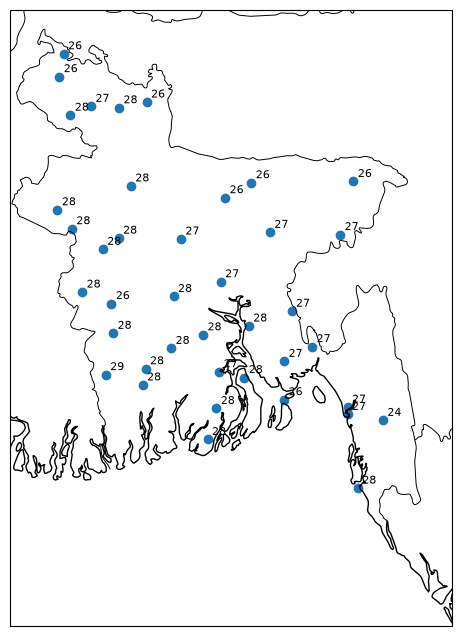

In [29]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([88, 93, 20, 27])

ax.coastlines(resolution="10m")

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.7
)

ax.scatter(
    obs["lon"],
    obs["lat"],
    transform=ccrs.PlateCarree()
)

for _, row in obs.iterrows():

    ax.text(
        row["lon"] + 0.05,
        row["lat"] + 0.05,
        f'{row["temp"]:.0f}',
        fontsize=8,
        transform=ccrs.PlateCarree()
    )

plt.show()

In [30]:
obs[[
    "name",
    "wind_dir",
    "wind_speed"
]].head(10)

,name,wind_dir,wind_speed
0,"TETULIA, PANCHAGOR",270.0,3
1,"DIMLA, NILPHAMARI",130.0,2
2,"RAJARHAT, KURIGRAM",90.0,1
3,SAIDPUR,310.0,5
4,RANGPUR,NaN,0
5,DINAJPUR,230.0,1
6,"BADALGACHHI, NAOGAON",180.0,3
7,BOGRA,NaN,0
8,MYMENSINGH,NaN,0
9,NETROKONA SADAR,30.0,1


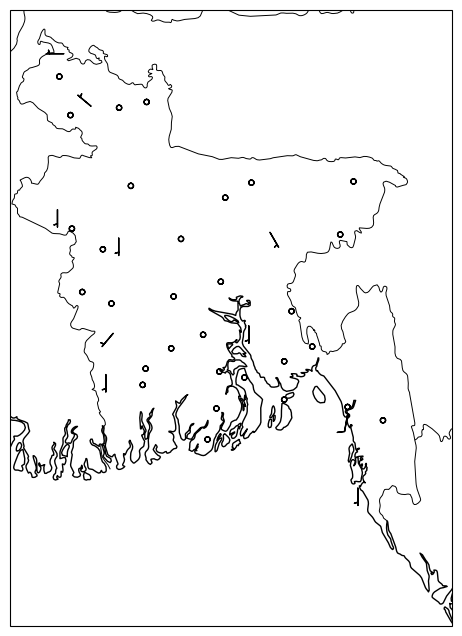

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([88, 93, 20, 27])

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.BORDERS, linewidth=0.7)

# Convert direction/speed to u,v
spd = obs["wind_speed"].fillna(0)

dir_deg = obs["wind_dir"].fillna(0)

u = -spd * np.sin(np.deg2rad(dir_deg))
v = -spd * np.cos(np.deg2rad(dir_deg))

ax.barbs(
    obs["lon"],
    obs["lat"],
    u,
    v,
    length=5,
    transform=ccrs.PlateCarree()
)

plt.show()

In [32]:
from metpy.plots import StationPlot

print("StationPlot imported successfully")

StationPlot imported successfully


In [33]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from metpy.plots import StationPlot

fig = plt.figure(figsize=(12, 9))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([88, 93, 20, 27])

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.BORDERS, linewidth=0.7)

stationplot = StationPlot(
    ax,
    obs["lon"].values,
    obs["lat"].values,
    transform=ccrs.PlateCarree(),
    fontsize=8
)

stationplot.plot_parameter(
    "NW",
    obs["temp"].values
)

stationplot.plot_parameter(
    "SW",
    obs["dewpoint"].values
)

stationplot.plot_barb(
    obs["wind_speed"].values,
    obs["wind_speed"].values * 0
)

plt.show()

ValueError: not enough values to unpack (expected 4, got 3)

<Figure size 1200x900 with 1 Axes>

In [34]:
import metpy
import matplotlib

print("MetPy:", metpy.__version__)
print("Matplotlib:", matplotlib.__version__)

MetPy: 1.7.1
Matplotlib: 3.11.0


In [35]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from metpy.plots import StationPlot

fig = plt.figure(figsize=(8, 6))

ax = plt.axes(projection=ccrs.PlateCarree())

stationplot = StationPlot(
    ax,
    [90],
    [24],
    transform=ccrs.PlateCarree()
)

stationplot.plot_parameter("NW", [26])

plt.show()

ValueError: not enough values to unpack (expected 4, got 3)

<Figure size 800x600 with 1 Axes>

In [36]:
import matplotlib
print(matplotlib.__file__)

/home/alnayeef/.conda/envs/Meteorology/lib/python3.12/site-packages/matplotlib/__init__.py


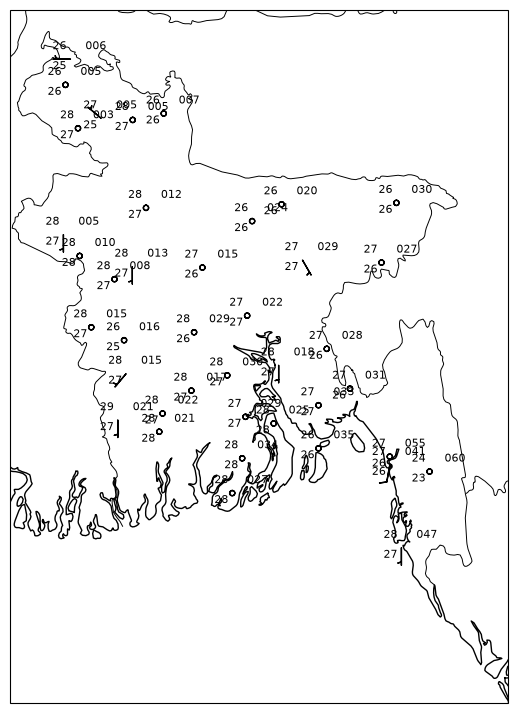

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 9))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([88, 93, 20, 27])

ax.coastlines("10m")
ax.add_feature(cfeature.BORDERS, linewidth=0.7)

# Wind components
spd = obs["wind_speed"].fillna(0)

dir_deg = obs["wind_dir"].fillna(0)

u = -spd * np.sin(np.deg2rad(dir_deg))
v = -spd * np.cos(np.deg2rad(dir_deg))

# Wind barbs
ax.barbs(
    obs["lon"],
    obs["lat"],
    u,
    v,
    length=5,
    transform=ccrs.PlateCarree()
)

# Temperature, dewpoint, pressure
for _, r in obs.iterrows():

    # WMO-style pressure code (last 3 digits)
    pcode = f"{int(round(r['slp'] * 10)) % 1000:03d}"

    ax.text(
        r["lon"] - 0.18,
        r["lat"] + 0.10,
        f"{r['temp']:.0f}",
        fontsize=8,
        transform=ccrs.PlateCarree()
    )

    ax.text(
        r["lon"] - 0.18,
        r["lat"] - 0.10,
        f"{r['dewpoint']:.0f}",
        fontsize=8,
        transform=ccrs.PlateCarree()
    )

    ax.text(
        r["lon"] + 0.15,
        r["lat"] + 0.10,
        pcode,
        fontsize=8,
        transform=ccrs.PlateCarree()
    )

plt.show()

In [38]:
import scipy

print(scipy.__version__)

1.18.0


In [43]:
import numpy as np
from scipy.interpolate import griddata

# Station locations
x = obs["lon"].values
y = obs["lat"].values
z = obs["slp"].values

# Grid over Bangladesh
grid_lon = np.linspace(88, 93, 250)
grid_lat = np.linspace(20, 27, 250)

LON, LAT = np.meshgrid(grid_lon, grid_lat)

# Interpolate
SLP = griddata(
    (x, y),
    z,
    (LON, LAT),
    method="cubic"
)

print(SLP.shape)

(250, 250)


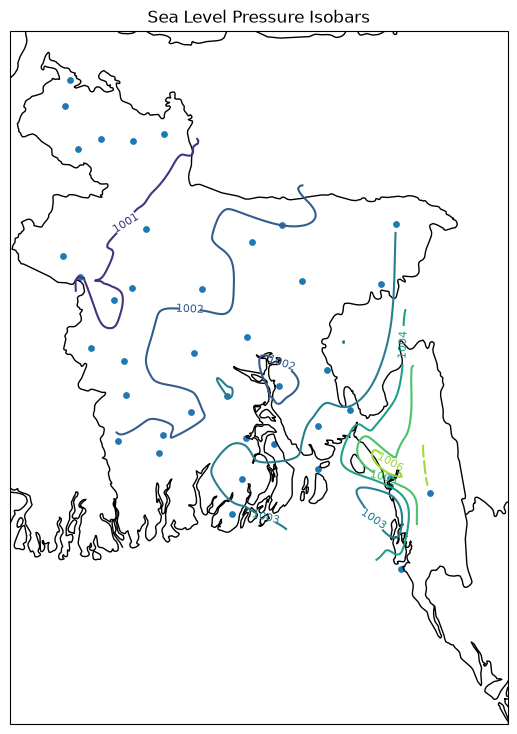

In [44]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 9))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([88, 93, 20, 27])

ax.coastlines("10m")
ax.add_feature(cfeature.BORDERS)

# Isobars every 1 hPa
levels = np.arange(
    np.floor(np.nanmin(SLP)),
    np.ceil(np.nanmax(SLP)) + 1,
    1
)

cs = ax.contour(
    LON,
    LAT,
    SLP,
    levels=levels,
    transform=ccrs.PlateCarree()
)

ax.clabel(
    cs,
    inline=True,
    fontsize=8
)

# Station locations
ax.scatter(
    obs["lon"],
    obs["lat"],
    s=15,
    transform=ccrs.PlateCarree()
)

plt.title("Sea Level Pressure Isobars")

plt.show()

In [45]:
print(obs["slp"].min())
print(obs["slp"].max())
print(obs["slp"].describe())

1000.3
1006.0
count      40.000000
mean     1002.237500
std         1.354137
min      1000.300000
25%      1001.275000
50%      1002.150000
75%      1002.925000
max      1006.000000
Name: slp, dtype: float64


In [46]:
import matplotlib.pyplot as plt
from metpy.plots import StationPlot

fig, ax = plt.subplots(figsize=(6,6))

sp = StationPlot(ax, [0], [0])

sp.plot_parameter("NW", [26])

plt.show()

ValueError: not enough values to unpack (expected 4, got 3)

<Figure size 600x600 with 1 Axes>

In [47]:
import inspect
from metpy.plots.text import TextCollection

print(inspect.getsource(TextCollection.draw))

    @allow_rasterization
    def draw(self, renderer):
        """Draw the :class:`TextCollection` object to the given *renderer*."""
        if renderer is not None:
            self._renderer = renderer
        if not self.get_visible():
            return
        if not any(self.text):
            return

        renderer.open_group('text', self.get_gid())

        trans = self.get_transform()
        if self.offset != (0, 0):
            scale = self.axes.figure.dpi / 72
            xoff, yoff = self.offset
            trans += mtransforms.Affine2D().translate(scale * xoff,
                                                      scale * yoff)

        posx = self.convert_xunits(self.x)
        posy = self.convert_yunits(self.y)
        pts = np.vstack((posx, posy)).T
        pts = trans.transform(pts)
        _, canvash = renderer.get_canvas_width_height()

        gc = renderer.new_gc()
        gc.set_foreground(self.get_color())
        gc.set_alpha(self.get_alpha())
        gc.set

<class 'tuple'>
3
[('26', (18.0, 10.552300347222223, 3.336588541666667), (0.0, -1.7763568394002505e-15))]
First item: ('26', (18.0, 10.552300347222223, 3.336588541666667), (0.0, -1.7763568394002505e-15))
Length: 3


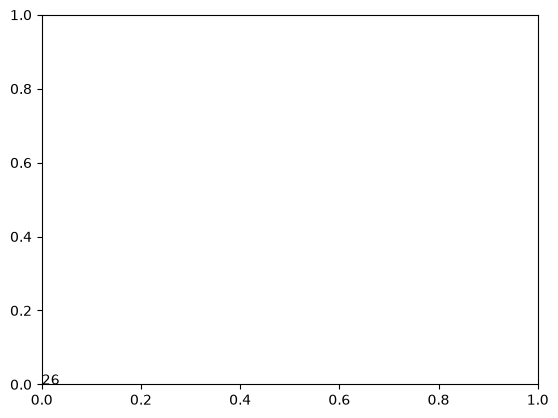

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

txt = ax.text(0, 0, "26")

layout = txt._get_layout(fig.canvas.get_renderer())

print(type(layout))
print(len(layout))

_, info, _ = layout

print(info)

print("First item:", info[0])
print("Length:", len(info[0]))

In [51]:
from weatherlab.decoder import decode_synop

decode_synop(
    "AAXX 08004 41850 ..."
)

NameError: name 'temp' is not defined

In [52]:
decode_synop(df.iloc[0]["REPORT"])

NameError: name 'temp' is not defined

In [53]:
import weatherlab.decoder

print(weatherlab.decoder.__file__)

/home/alnayeef/Documents/MetLb-310/WeatherLab/weatherlab/decoder.py


In [54]:
import inspect
from weatherlab.decoder import decode_synop

print(inspect.getsource(decode_synop))

def decode_synop(report):

    data = synop.SYNOP().decode(report)

    temp = None
    dewpoint = None
    slp = None
    wind_dir = None
    wind_speed = None

    try:
        temp = data["air_temperature"]["value"]
    except:
        pass

    try:
        dewpoint = data["dewpoint_temperature"]["value"]
    except:
        pass

    try:
        slp = data["station_pressure"]["value"]
    except:
        pass

    try:
        wind_dir = data["surface_wind"]["direction"]["value"]
    except:
        pass

    try:
        wind_speed = data["surface_wind"]["speed"]["value"]
    except:
        pass

    return {
        "temp": temp,
        "dewpoint": dewpoint,
        "slp": slp,
        "wind_dir": wind_dir,
        "wind_speed": wind_speed,
    }



In [55]:
from weatherlab.decoder import decode_synop

report = df.iloc[0]["REPORT"]

decode_synop(report)

NameError: name 'temp' is not defined

In [56]:
from weatherlab.decoder import decode_synop
import inspect

print(decode_synop)
print(decode_synop.__code__.co_firstlineno)
print(inspect.getsource(decode_synop))

<function decode_synop at 0x7f3fd78a8400>
3
def decode_synop(report):

    data = synop.SYNOP().decode(report)

    temp = None
    dewpoint = None
    slp = None
    wind_dir = None
    wind_speed = None

    try:
        temp = data["air_temperature"]["value"]
    except:
        pass

    try:
        dewpoint = data["dewpoint_temperature"]["value"]
    except:
        pass

    try:
        slp = data["station_pressure"]["value"]
    except:
        pass

    try:
        wind_dir = data["surface_wind"]["direction"]["value"]
    except:
        pass

    try:
        wind_speed = data["surface_wind"]["speed"]["value"]
    except:
        pass

    return {
        "temp": temp,
        "dewpoint": dewpoint,
        "slp": slp,
        "wind_dir": wind_dir,
        "wind_speed": wind_speed,
    }



In [57]:
import weatherlab.decoder

print(weatherlab.decoder.__file__)

/home/alnayeef/Documents/MetLb-310/WeatherLab/weatherlab/decoder.py


In [1]:
from weatherlab.decoder import decode_synop
import inspect

print(inspect.getsource(decode_synop))

ModuleNotFoundError: No module named 'weatherlab'

In [6]:
import os
print(os.getcwd())

/home/alnayeef/Documents/MetLb-310/WeatherLab/notebooks


In [4]:
import sys
from pathlib import Path

sys.path.append(
    str(Path.cwd().parent)
)

In [5]:
from weatherlab.decoder import decode_synop

In [6]:
import weatherlab

print(weatherlab.__file__)

/home/alnayeef/Documents/MetLb-310/WeatherLab/weatherlab/__init__.py


In [7]:
report = df.iloc[0]["REPORT"]

decode_synop(report)

NameError: name 'df' is not defined

In [8]:
%whos

Variable       Type        Data/Info
------------------------------------
Path           type        <class 'pathlib.Path'>
decode_synop   function    <function decode_synop at 0x7f187c1b14e0>
os             module      <module 'os' (frozen)>
sys            module      <module 'sys' (built-in)>
weatherlab     module      <module 'weatherlab' from<...>/weatherlab/__init__.py'>


In [30]:
%whos

Variable        Type         Data/Info
--------------------------------------
Path            type         <class 'pathlib.Path'>
UTC             timezone     UTC
datetime        type         <class 'datetime.datetime'>
decode_synop    function     <function decode_synop at 0x7f187c1b14e0>
df              DataFrame    Shape: (0, 7)
get_raw_synop   function     <function get_raw_synop at 0x7f1865eca3e0>
now             datetime     2026-07-08 12:00:48.392601+00:00
os              module       <module 'os' (frozen)>
pd              module       <module 'pandas' from '/h<...>ages/pandas/__init__.py'>
requests        module       <module 'requests' from '<...>es/requests/__init__.py'>
sys             module       <module 'sys' (built-in)>
timedelta       type         <class 'datetime.timedelta'>
weatherlab      module       <module 'weatherlab' from<...>/weatherlab/__init__.py'>


In [31]:
from weatherlab.analysis import wind_components
from weatherlab.interpolate import pressure_field

In [32]:
from weatherlab.interpolate import pressure_field
from weatherlab.plotting import (
    create_map,
    plot_isobars
)

LON, LAT, SLP = pressure_field(obs)

fig, ax = create_map()

plot_isobars(
    ax,
    LON,
    LAT,
    SLP
)

plt.show()

ImportError: cannot import name 'create_map' from 'weatherlab.plotting' (/home/alnayeef/Documents/MetLb-310/WeatherLab/weatherlab/plotting.py)

In [33]:
import weatherlab.plotting as p

print(dir(p))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'ccrs', 'np', 'plot_isobars']


In [1]:
import weatherlab.plotting as p

print(dir(p))

ModuleNotFoundError: No module named 'weatherlab'

In [2]:
import os

print(os.getcwd())

/home/alnayeef/Documents/MetLb-310/WeatherLab/notebooks


In [3]:
import sys
from pathlib import Path

sys.path.append(
    str(Path.cwd().parent)
)

import weatherlab

print(weatherlab)

<module 'weatherlab' from '/home/alnayeef/Documents/MetLb-310/WeatherLab/weatherlab/__init__.py'>


In [4]:
import weatherlab.plotting as p

print(dir(p))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'ccrs', 'cfeature', 'create_map', 'np', 'plot_isobars', 'plt']


<class 'matplotlib.figure.Figure'>
<class 'cartopy.mpl.geoaxes.GeoAxes'>


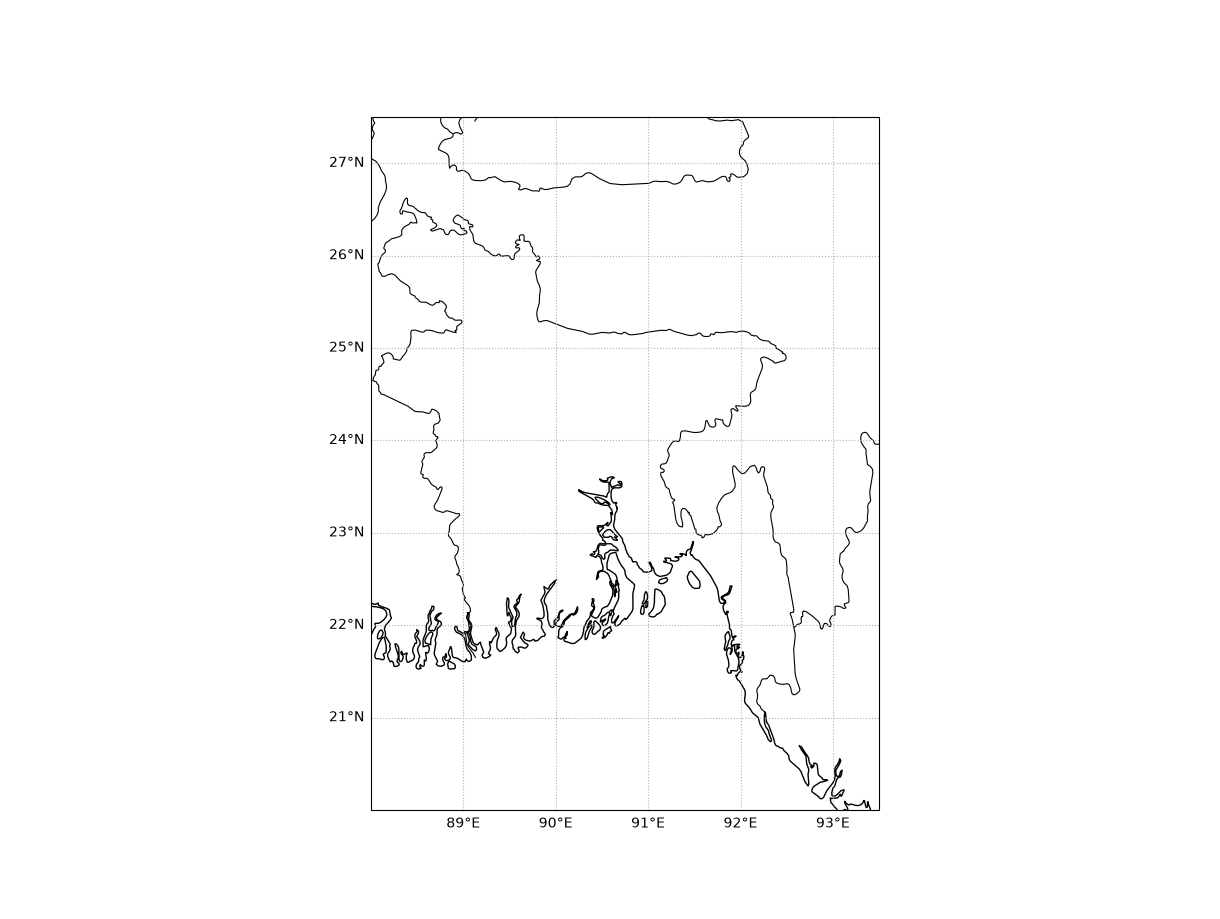

In [5]:
from weatherlab.plotting import create_map

fig, ax = create_map()

print(type(fig))
print(type(ax))

In [6]:
from weatherlab.interpolate import pressure_field

LON, LAT, SLP = pressure_field(obs)

print(LON.shape)
print(LAT.shape)
print(SLP.shape)

NameError: name 'obs' is not defined

In [7]:
whos

Variable         Type        Data/Info
--------------------------------------
Path             type        <class 'pathlib.Path'>
ax               GeoAxes     < GeoAxes: +proj=eqc +ell<...>er=1 +no_defs +type=crs >
create_map       function    <function create_map at 0x7f9dc0b6b880>
fig              Figure      Figure(1200x900)
os               module      <module 'os' (frozen)>
p                module      <module 'weatherlab.plott<...>/weatherlab/plotting.py'>
pressure_field   function    <function pressure_field at 0x7f9dd6e5e840>
sys              module      <module 'sys' (built-in)>
weatherlab       module      <module 'weatherlab' from<...>/weatherlab/__init__.py'>


In [8]:
from weatherlab import latest_surface_obs

obs = latest_surface_obs()

print(obs.shape)

obs.head()

https://www.ogimet.com/cgi-bin/getsynop?begin=202607081200&end=202607081200&state=Bang&lang=eng
(38, 14)


,wmo,temp,dewpoint,slp,wind_dir,wind_speed,wigos,name,country,lat,lon,elev,status,type
0,41850,28.6,26.0,989.2,90.0,2,0-20000-0-41850,"TETULIA, PANCHAGOR",Bangladesh,26.344167,88.607222,NaN,Operational,Land (fixed)
1,41851,29.5,27.0,992.9,NaN,0,0-20000-0-41851,"DIMLA, NILPHAMARI",Bangladesh,26.085833,88.557500,54.0,Operational,Land (fixed)
2,41856,28.5,27.0,995.9,NaN,0,0-20000-0-41856,"RAJARHAT, KURIGRAM",Bangladesh,25.798333,89.545000,31.0,Operational,Land (fixed)
3,41858,30.0,25.0,994.7,NaN,0,0-20000-0-41858,SAIDPUR,Bangladesh,25.750000,88.916667,44.0,Operational,Land (fixed)
4,41859,29.6,28.0,995.6,130.0,2,0-20000-0-41859,RANGPUR,Bangladesh,25.733333,89.233333,34.0,Operational,Land (fixed)


In [12]:
from weatherlab.interpolate import pressure_field

LON, LAT, SLP = pressure_field(obs)

print(LON.shape)
print(LAT.shape)
print(SLP.shape)

print("Min SLP:", SLP.min())
print("Max SLP:", SLP.max())

(250, 250)
(250, 250)
(250, 250)
Min SLP: nan
Max SLP: nan


In [13]:
print(obs[["lat", "lon", "slp"]].head())

print(obs["slp"].isna().sum())
print(len(obs))

         lat        lon    slp
0  26.344167  88.607222  989.2
1  26.085833  88.557500  992.9
2  25.798333  89.545000  995.9
3  25.750000  88.916667  994.7
4  25.733333  89.233333  995.6
0
38


In [14]:
print(obs["slp"].min())
print(obs["slp"].max())

989.2
1004.2


In [18]:
import numpy as np
LON, LAT, SLP = pressure_field(
    obs,
    method="cubic"
)

print(np.isnan(SLP).sum())
print(SLP.size)

37542
62500


In [19]:
LON, LAT, SLP = pressure_field(obs)

print(np.isnan(SLP).sum())

37542


In [20]:
import inspect
from weatherlab.interpolate import pressure_field

print(inspect.getsource(pressure_field))

def pressure_field(
    obs,
    resolution=250,
    method="cubic"
):

    x = obs["lon"].values
    y = obs["lat"].values
    z = obs["slp"].values

    lon_min = x.min() - 0.5
    lon_max = x.max() + 0.5

    lat_min = y.min() - 0.5
    lat_max = y.max() + 0.5

    grid_lon = np.linspace(
        lon_min,
        lon_max,
        resolution
    )

    grid_lat = np.linspace(
        lat_min,
        lat_max,
        resolution
    )

    LON, LAT = np.meshgrid(
        grid_lon,
        grid_lat
    )

    SLP = griddata(
        (x, y),
        z,
        (LON, LAT),
        method=method
    )

    mask = np.isnan(SLP)

    if np.any(mask):
        SLP[mask] = griddata(
            (x, y),
            z,
            (LON[mask], LAT[mask]),
            method="nearest"
        )

    return LON, LAT, SLP



In [21]:
from scipy.interpolate import griddata
import numpy as np

x = obs["lon"].values
y = obs["lat"].values
z = obs["slp"].values

LON, LAT, SLP = pressure_field(
    obs,
    method="cubic"
)

mask = np.isnan(SLP)

print("NaNs before fill:", mask.sum())

filled = griddata(
    (x, y),
    z,
    (LON[mask], LAT[mask]),
    method="nearest"
)

print("Filled shape:", filled.shape)
print("NaNs in fill:", np.isnan(filled).sum())
print("First 10 values:", filled[:10])

NaNs before fill: 37542
Filled shape: (37542,)
NaNs in fill: 0
First 10 values: [1000.7 1000.7 1000.7 1000.7 1000.7 1000.7 1000.7 1000.7 1000.7 1000.7]


In [22]:
from weatherlab.interpolate import pressure_field
from scipy.interpolate import griddata
import numpy as np

x = obs["lon"].values
y = obs["lat"].values
z = obs["slp"].values

LON, LAT, SLP = pressure_field(obs, method="cubic")

print("Before:", np.isnan(SLP).sum())

mask = np.isnan(SLP)

SLP[mask] = griddata(
    (x, y),
    z,
    (LON[mask], LAT[mask]),
    method="nearest"
)

print("After:", np.isnan(SLP).sum())

Before: 37542
After: 0


In [23]:
import importlib
import weatherlab.interpolate

importlib.reload(weatherlab.interpolate)

from weatherlab.interpolate import pressure_field

LON, LAT, SLP = pressure_field(obs)

print(np.isnan(SLP).sum())

0


NameError: name 'plot_isobars' is not defined

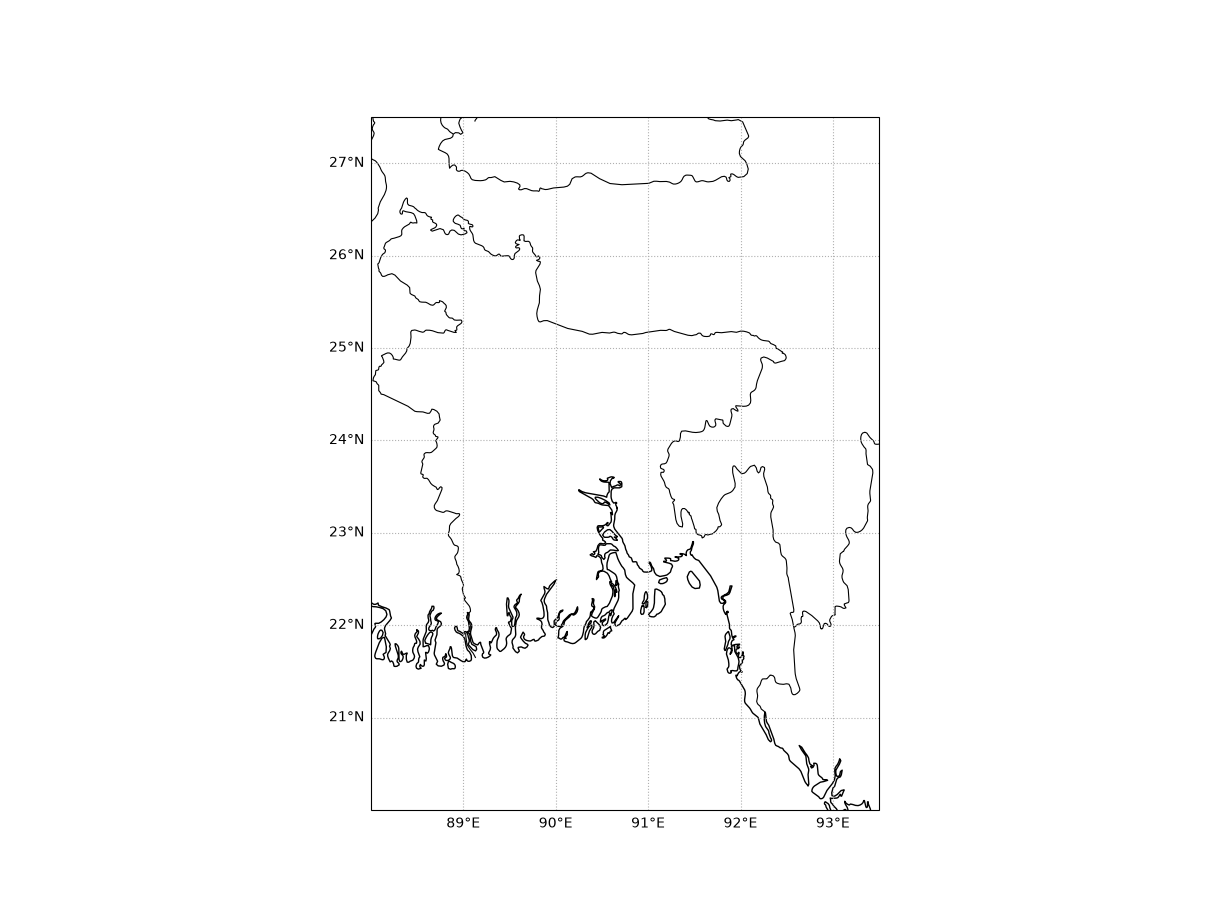

In [24]:
fig, ax = create_map()

plot_isobars(
    ax,
    LON,
    LAT,
    SLP
)

plt.show()

In [25]:
from weatherlab.plotting import plot_isobars

In [26]:
print(plot_isobars)

<function plot_isobars at 0x7f9d4bbca8e0>


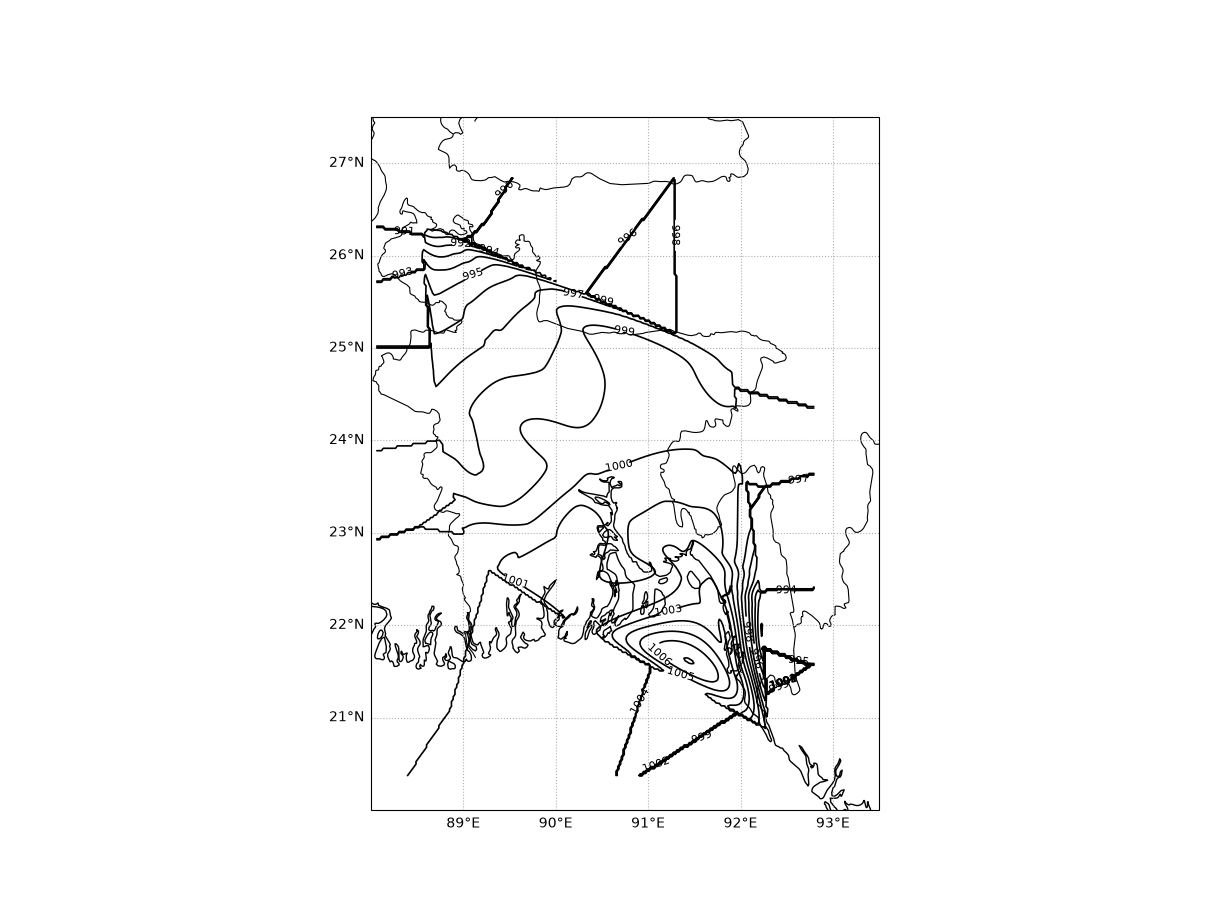

In [29]:
import matplotlib.pyplot as plt
fig, ax = create_map()

plot_isobars(
    ax,
    LON,
    LAT,
    SLP
)

plt.show()

In [30]:
import metpy
import matplotlib

print(metpy.__version__)
print(matplotlib.__version__)

1.7.1
3.11.0
